```python
import kagglehub
path = kagglehub.dataset_download("wisnuanggara/daftar-harga-rumah")
print("Path to dataset files:", path)
https://www.kaggle.com/datasets/wisnuanggara/daftar-harga-rumah
```

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from math import sqrt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Load
df = pd.read_excel("./data/DATA RUMAH.xlsx")
print("Shape:", df.shape)
display(df.head())

Shape: (1010, 8)


,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS
0,1,"Rumah Murah Hook Tebet Timur, Tebet, Jakarta S...",3800000000,220,220,3,3,0
1,2,"Rumah Modern di Tebet dekat Stasiun, Tebet, Ja...",4600000000,180,137,4,3,2
2,3,"Rumah Mewah 2 Lantai Hanya 3 Menit Ke Tebet, T...",3000000000,267,250,4,4,4
3,4,"Rumah Baru Tebet, Tebet, Jakarta Selatan",430000000,40,25,2,2,0
4,5,"Rumah Bagus Tebet komp Gudang Peluru lt 350m, ...",9000000000,400,355,6,5,3


In [3]:
# 2. Extract simple CITY and SUBAREA from NAMA RUMAH
def extract_city(name):
    if not isinstance(name, str): return "Unknown"
    cities = ["Jakarta Selatan","Jakarta Timur","Jakarta Barat","Jakarta Pusat","Jakarta Utara","Jakarta"]
    for c in cities:
        if c.lower() in name.lower(): return c
    parts = [p.strip() for p in name.split(',') if p.strip()!='']
    return parts[-1] if parts else "Unknown"

def extract_subarea(name):
    if not isinstance(name, str): return "Unknown"
    common = ["Tebet","Mampang","Pancoran","Setiabudi","Kebayoran","Gudang Peluru","Kemang"]
    for s in common:
        if s.lower() in name.lower(): return s
    parts = [p.strip() for p in name.split(',') if p.strip()!='']
    return parts[0] if parts else "Unknown"

df['CITY'] = df['NAMA RUMAH'].apply(extract_city)
df['SUBAREA'] = df['NAMA RUMAH'].apply(extract_subarea)

In [4]:
# 3. Ensure numeric and drop rows with missing essentials
for c in ['HARGA','LB','LT','KT','KM','GRS']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['HARGA','LB','LT']).reset_index(drop=True)

In [5]:
# 4. Inspect price percentiles (print)
print("HARGA percentiles:\n", df['HARGA'].quantile([0,0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99,1.0]))

HARGA percentiles:
 0.00    4.300000e+08
0.01    8.545000e+08
0.05    2.000000e+09
0.10    2.500000e+09
0.25    3.262500e+09
0.50    5.000000e+09
0.75    9.000000e+09
0.90    1.650000e+10
0.95    2.300000e+10
0.99    3.500000e+10
1.00    6.500000e+10
Name: HARGA, dtype: float64


In [6]:
# 5. Trim extreme HARGA (1%-99%) and winsorize LB/LT at 1%-99%
low_p, high_p = df['HARGA'].quantile(0.01), df['HARGA'].quantile(0.99)
df_trim = df[(df['HARGA'] >= low_p) & (df['HARGA'] <= high_p)].copy().reset_index(drop=True)
for col in ['LB','LT']:
    l,h = df_trim[col].quantile(0.01), df_trim[col].quantile(0.99)
    df_trim[col] = np.where(df_trim[col] < l, l, df_trim[col])
    df_trim[col] = np.where(df_trim[col] > h, h, df_trim[col])

In [7]:

# 6. Transform target to log-scale and make derived features
df_trim['HARGA_LOG'] = np.log1p(df_trim['HARGA'])
df_trim['PRICE_PER_LB'] = df_trim['HARGA'] / df_trim['LB']
df_trim['PRICE_PER_LT'] = df_trim['HARGA'] / df_trim['LT']
df_trim.replace([np.inf, -np.inf], np.nan, inplace=True)
df_trim.dropna(subset=['PRICE_PER_LB','PRICE_PER_LT'], inplace=True)


In [8]:
# 7. One-hot encode top CITY & SUBAREA (limit categories)
top_cities = df_trim['CITY'].value_counts().nlargest(6).index.tolist()
df_trim['CITY_MOD'] = df_trim['CITY'].apply(lambda x: x if x in top_cities else 'Other')
top_sub = df_trim['SUBAREA'].value_counts().nlargest(12).index.tolist()
df_trim['SUB_MOD'] = df_trim['SUBAREA'].apply(lambda x: x if x in top_sub else 'Other')
df_model = pd.get_dummies(df_trim, columns=['CITY_MOD','SUB_MOD'], drop_first=True)


In [9]:
# drop textual cols not used
df_model = df_model.drop(columns=['NO','NAMA RUMAH','CITY','SUBAREA'], errors='ignore')

In [10]:
# 8. Prepare X,y and scale numeric features
y = df_model['HARGA_LOG']
X = df_model.drop(columns=['HARGA','HARGA_LOG'])
numeric_feats = ['LB','LT','KT','KM','GRS','PRICE_PER_LB','PRICE_PER_LT']
scaler = StandardScaler()
X[numeric_feats] = scaler.fit_transform(X[numeric_feats])


In [11]:
# 9. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# 10. Train baseline models
lr = LinearRegression(); lr.fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=120, random_state=42); rf.fit(X_train, y_train)
gbr = GradientBoostingRegressor(n_estimators=120, learning_rate=0.05, max_depth=3, random_state=42); gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,120
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [13]:
# evaluation helper (returns metrics on real scale)
def eval_model(m, X_test, y_test, name):
    y_pred_log = m.predict(X_test)
    y_test_real = np.expm1(y_test); y_pred_real = np.expm1(y_pred_log)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = sqrt(mean_squared_error(y_test_real, y_pred_real))
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
    r2 = r2_score(y_test_real, y_pred_real)
    print(f"{name}: R2={r2:.4f}, MAE={mae:,.2f}, RMSE={rmse:,.2f}, MAPE={mape:.2f}%")
    return {'r2':r2,'mae':mae,'rmse':rmse,'mape':mape}, y_test_real, y_pred_real

res_lr, y_t_lr, y_p_lr = eval_model(lr, X_test, y_test, "LinearRegression")
res_rf, y_t_rf, y_p_rf = eval_model(rf, X_test, y_test, "RandomForest")
res_gbr, y_t_gbr, y_p_gbr = eval_model(gbr, X_test, y_test, "GradientBoosting")

LinearRegression: R2=0.7028, MAE=1,114,670,525.30, RMSE=2,862,640,347.91, MAPE=15.07%
RandomForest: R2=0.9852, MAE=220,811,247.14, RMSE=638,883,725.19, MAPE=3.16%
GradientBoosting: R2=0.9831, MAE=274,710,452.62, RMSE=682,478,818.33, MAPE=3.95%


In [14]:
# 11. Small GridSearch tuning (light)
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), {'n_estimators':[100,150], 'max_depth':[None,10]}, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("RF best params:", rf_grid.best_params_)
res_rf_best, y_t_rf_best, y_p_rf_best = eval_model(best_rf, X_test, y_test, "RF_tuned")


RF best params: {'max_depth': None, 'n_estimators': 150}
RF_tuned: R2=0.9862, MAE=211,444,422.33, RMSE=617,203,253.01, MAPE=2.99%


In [15]:

gbr_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), {'n_estimators':[100,150], 'learning_rate':[0.03,0.05]}, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
gbr_grid.fit(X_train, y_train)
best_gbr = gbr_grid.best_estimator_
print("GBR best params:", gbr_grid.best_params_)
res_gbr_best, y_t_gbr_best, y_p_gbr_best = eval_model(best_gbr, X_test, y_test, "GBR_tuned")


GBR best params: {'learning_rate': 0.05, 'n_estimators': 150}
GBR_tuned: R2=0.9856, MAE=252,472,745.59, RMSE=631,062,157.00, MAPE=3.69%


In [16]:
# 12. Compare and plot best by MAE
summary = pd.DataFrame({
    'model':['LR','RF','GBR','RF_tuned','GBR_tuned'],
    'r2':[res_lr['r2'],res_rf['r2'],res_gbr['r2'],res_rf_best['r2'],res_gbr_best['r2']],
    'mae':[res_lr['mae'],res_rf['mae'],res_gbr['mae'],res_rf_best['mae'],res_gbr_best['mae']],
    'rmse':[res_lr['rmse'],res_rf['rmse'],res_gbr['rmse'],res_rf_best['rmse'],res_gbr_best['rmse']],
    'mape':[res_lr['mape'],res_rf['mape'],res_gbr['mape'],res_rf_best['mape'],res_gbr_best['mape']]
})
display(summary)

best = summary.sort_values('mae').iloc[0]['model']
print("Best model by MAE:", best)
if best=='LR': yt, yp = y_t_lr, y_p_lr
elif best=='RF': yt, yp = y_t_rf, y_p_rf
elif best=='GBR': yt, yp = y_t_gbr, y_p_gbr
elif best=='RF_tuned': yt, yp = y_t_rf_best, y_p_rf_best
else: yt, yp = y_t_gbr_best, y_p_gbr_best

,model,r2,mae,rmse,mape
0,LR,0.702833,1.114671e+09,2.862640e+09,15.069351
1,RF,0.985198,2.208112e+08,6.388837e+08,3.158114
2,GBR,0.983109,2.747105e+08,6.824788e+08,3.947192
3,RF_tuned,0.986186,2.114444e+08,6.172033e+08,2.990195
4,GBR_tuned,0.985559,2.524727e+08,6.310622e+08,3.685937


Best model by MAE: RF_tuned


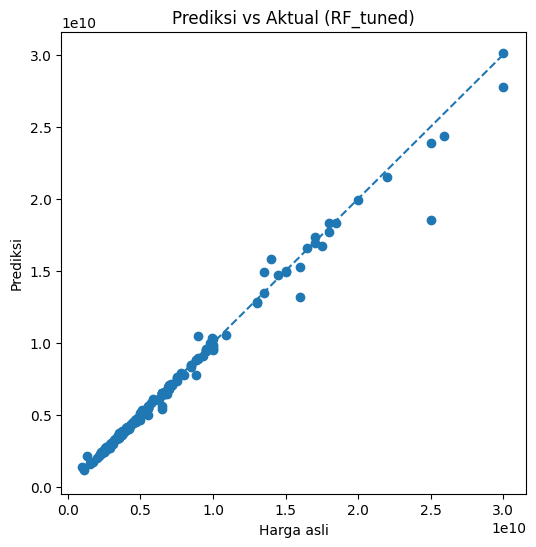

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(yt, yp)
mn, mx = min(yt.min(), yp.min()), max(yt.max(), yp.max())
plt.plot([mn,mx],[mn,mx], linestyle='--')
plt.xlabel("Harga asli"); plt.ylabel("Prediksi"); plt.title(f"Prediksi vs Aktual ({best})")
plt.show()


LT                                                                             7.081342e-01
PRICE_PER_LT                                                                   1.805621e-01
LB                                                                             6.493245e-02
PRICE_PER_LB                                                                   4.250034e-02
KT                                                                             1.294554e-03
KM                                                                             9.749539e-04
GRS                                                                            9.691568e-04
CITY_MOD_Jakarta Selatan                                                       2.162297e-04
CITY_MOD_Other                                                                 1.551096e-04
SUB_MOD_Tebet                                                                  1.137252e-04
SUB_MOD_Other                                                                  9

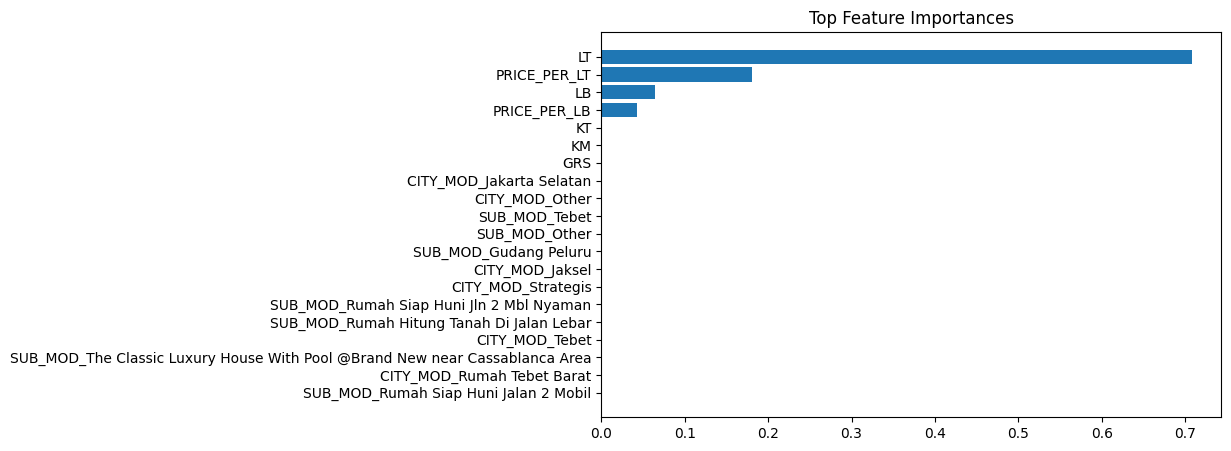

In [18]:
# 13. Feature importances (if tree model best)
if 'RF' in best or 'GBR' in best:
    model_imp = best_rf if 'RF' in best else best_gbr
    imp = pd.Series(model_imp.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
    display(imp)
    plt.figure(figsize=(8,5))
    plt.barh(imp.index[::-1], imp.values[::-1])
    plt.title("Top Feature Importances")
    plt.show()